# Evaluation: Comparison of Report Generation Approaches

Three methods: **baseline_rag**, **mmr_rag**, **raw_generation**  
Data is loaded directly from experiment CSV files.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
from pathlib import Path
from scipy import stats
from itertools import combinations

# ── Violet / purple palette ───────────────────────────────────────────────────
PURPLE = {
    "deep":     "#5B3DC8",   # deep indigo-violet
    "mid":      "#9575CD",   # medium violet
    "light":    "#C9B8F0",   # light lavender
    "positive": "#7C3AED",   # vivid violet  (δ better)
    "negative": "#C06B8E",   # muted rose     (δ worse)
    "grid":     "#EDE9FE",   # very light lavender for backgrounds
}

METHOD_COLORS = {
    "baseline_rag":   PURPLE["deep"],
    "mmr_rag":        PURPLE["mid"],
    "raw_generation": PURPLE["light"],
}
LANG_COLORS = {
    "Ukrainian": PURPLE["deep"],
    "English":   "#B39DDB",  # soft lavender — distinct but same family
}

sns.set_theme(
    style="whitegrid",
    font_scale=1.05,
    rc={
        "axes.facecolor":    "#FAFAFE",
        "figure.facecolor":  "#FFFFFF",
        "grid.color":        "#E9E4F8",
        "axes.edgecolor":    "#C4B9EB",
        "axes.spines.top":   False,
        "axes.spines.right": False,
    },
)

EXPERIMENTS = Path("../../experiments")

METRIC_COLS = [
    "faithfulness_report",
    "answer_relevancy_report",
    "diversity",
    "temporal_coverage",
    "context_precision",
]
TECH_COLS = ["report_tokens_used", "report_generation_time"]

METRIC_LABELS = {
    "faithfulness_report":     "Faithfulness",
    "answer_relevancy_report": "Answer Relevancy",
    "diversity":               "Diversity",
    "temporal_coverage":       "Temporal Coverage",
    "context_precision":       "Context Precision",
}
TECH_LABELS = {
    "report_tokens_used":     "Tokens (report)",
    "report_generation_time": "Generation Time (s)",
}
PERIOD_LABELS = {"week": "Week", "month": "Month", "year": "Year"}
PERIOD_ORDER  = ["week", "month", "year"]


In [2]:
dfs = []
for fname in ["results_baseline_rag.csv", "results_mmr_rag.csv", "results_raw_generation_full.csv"]:
    tmp = pd.read_csv(EXPERIMENTS / fname)
    tmp = tmp.rename(columns={"user_id": "userId"})
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)

KEEP = ["method", "period_type", "period_start", "userId"] + METRIC_COLS + TECH_COLS + ["temporal_breadth"]
df = df[[c for c in KEEP if c in df.columns]].copy()

for col in METRIC_COLS + TECH_COLS + ["temporal_breadth"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

METHODS = sorted(df["method"].unique())

print(f"Total rows: {len(df)}")
print()
print(df.groupby(["method", "period_type"]).size().rename("count").to_string())


Total rows: 1051

method          period_type
baseline_rag    month           63
                week           275
                year            10
mmr_rag         month           65
                week           274
                year            10
raw_generation  month           65
                week           279
                year            10


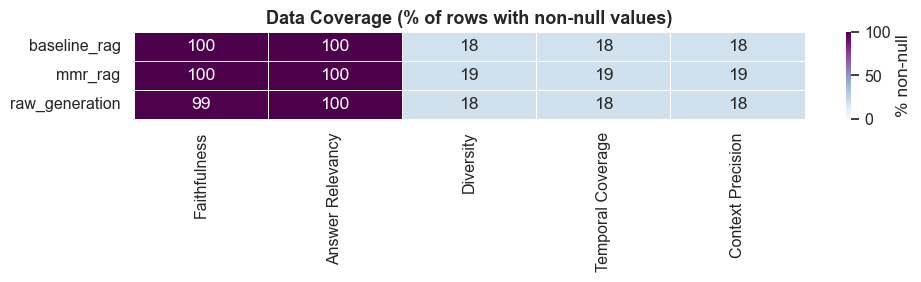


Note: diversity / temporal_coverage / context_precision — month and year only.


In [3]:
# Data coverage — how many rows each metric has
cov = df.groupby("method")[METRIC_COLS].apply(lambda g: g.notna().mean() * 100)
cov.columns = [METRIC_LABELS[c] for c in METRIC_COLS]

fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(
    cov, annot=True, fmt=".0f", cmap="BuPu",
    vmin=0, vmax=100, linewidths=0.6, linecolor="white",
    cbar_kws={"label": "% non-null"}, ax=ax
)
ax.set_title("Data Coverage (% of rows with non-null values)", fontsize=13, fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("\nNote: diversity / temporal_coverage / context_precision — month and year only.")


---
## 1. Core Quality Metrics by Method


C:\Users\alina\AppData\Local\Temp\ipykernel_1568\2184451906.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\alina\AppData\Local\Temp\ipykernel_1568\2184451906.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
C:\Users\alina\AppData\Local\Temp\ipykernel_1568\2184451906.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\alina\AppData\Local\Temp\ipykernel_1568\2184451906.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

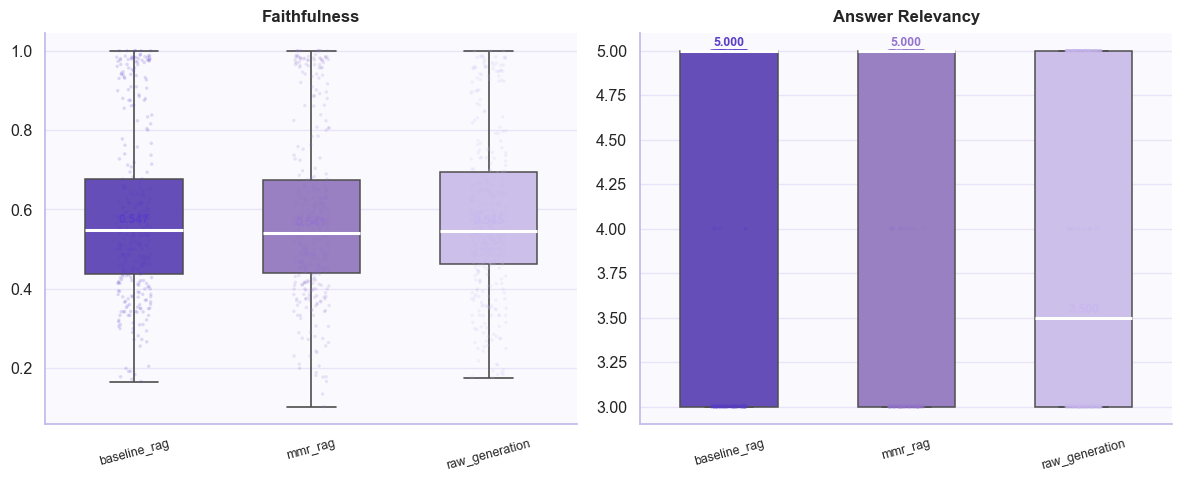

In [4]:
FULL_METRICS = ["faithfulness_report", "answer_relevancy_report"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, FULL_METRICS):
    sns.boxplot(
        data=df, x="method", y=metric, order=METHODS,
        palette=METHOD_COLORS, linewidth=1.1, width=0.55,
        medianprops={"color": "white", "linewidth": 2.2},
        whiskerprops={"linewidth": 1.2},
        capprops={"linewidth": 1.2},
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.35, "markeredgewidth": 0},
        ax=ax,
    )
    sns.stripplot(
        data=df, x="method", y=metric, order=METHODS,
        palette=METHOD_COLORS, alpha=0.18, jitter=True, size=2.5,
        ax=ax, zorder=2,
    )
    for i, method in enumerate(METHODS):
        vals = df[df["method"] == method][metric].dropna().values
        if len(vals):
            med = np.median(vals)
            ax.text(i, med + 0.012, f"{med:.3f}",
                    ha="center", va="bottom", fontsize=9, fontweight="bold",
                    color=METHOD_COLORS[method])

    ax.set_title(METRIC_LABELS[metric], fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=15, labelsize=9)

plt.tight_layout()
plt.show()

C:\Users\alina\AppData\Local\Temp\ipykernel_1568\1985559120.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\alina\AppData\Local\Temp\ipykernel_1568\1985559120.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\alina\AppData\Local\Temp\ipykernel_1568\1985559120.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\alina\AppData\Local\Temp\ipykernel_1568\1985559120.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

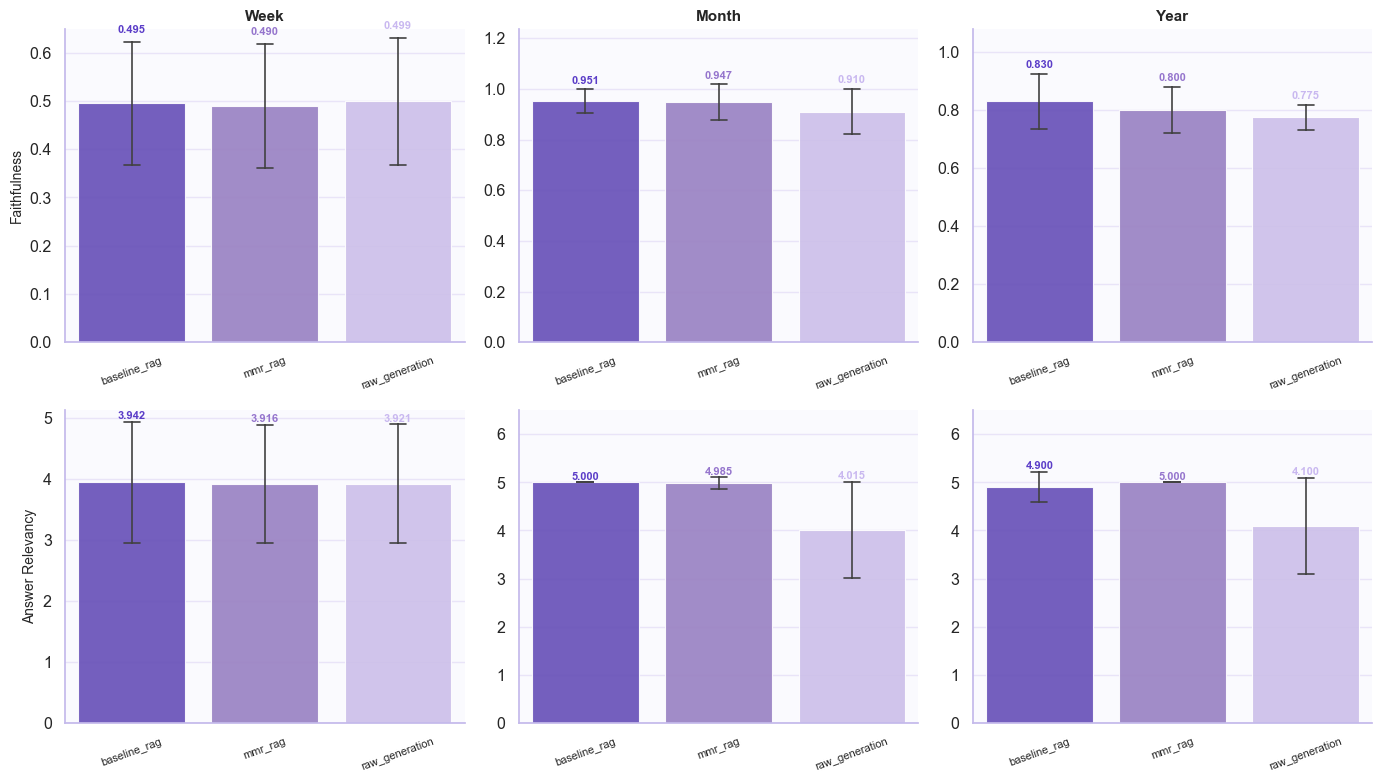

In [5]:
fig, axes = plt.subplots(2, len(PERIOD_ORDER), figsize=(14, 8), sharey=False)

for row, metric in enumerate(FULL_METRICS):
    for col, period in enumerate(PERIOD_ORDER):
        ax = axes[row][col]
        sub = df[df["period_type"] == period]

        sns.barplot(
            data=sub, x="method", y=metric, order=METHODS,
            palette=METHOD_COLORS, errorbar="sd", capsize=0.12,
            err_kws={"linewidth": 1.2},
            edgecolor="white", linewidth=0.8, alpha=0.9,
            ax=ax,
        )
        means = sub.groupby("method")[metric].mean().reindex(METHODS)
        stds  = sub.groupby("method")[metric].std().reindex(METHODS).fillna(0)
        for i, (val, std) in enumerate(zip(means.values, stds.values)):
            if not np.isnan(val):
                ax.text(i, val + std + 0.015, f"{val:.3f}",
                        ha="center", va="bottom", fontsize=8, fontweight="bold",
                        color=METHOD_COLORS[METHODS[i]])

        if row == 0:
            ax.set_title(PERIOD_LABELS[period], fontsize=11, fontweight="bold")
        if col == 0:
            ax.set_ylabel(METRIC_LABELS[metric], fontsize=10)
        else:
            ax.set_ylabel("")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=20, labelsize=8)
        valid = [v for v in means.dropna().values]
        if valid:
            ax.set_ylim(0, max(valid) * 1.3)

plt.tight_layout()
plt.show()


---
## 2. RAG-Specific Metrics (month + year)

Metrics `diversity`, `temporal_coverage`, `context_precision` were measured for monthly and yearly reports only.


C:\Users\alina\AppData\Local\Temp\ipykernel_1568\2493282968.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\alina\AppData\Local\Temp\ipykernel_1568\2493282968.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\alina\AppData\Local\Temp\ipykernel_1568\2493282968.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


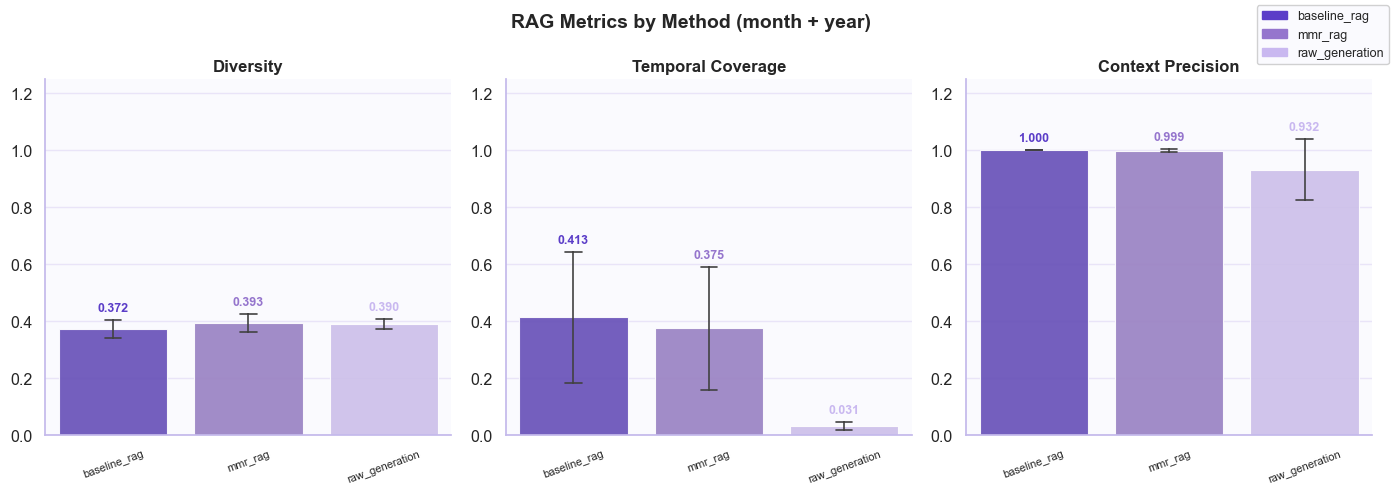

In [6]:
RAG_METRICS = ["diversity", "temporal_coverage", "context_precision"]
df_rag = df[df["period_type"].isin(["month", "year"])].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("RAG Metrics by Method (month + year)", fontsize=14, fontweight="bold")

for ax, metric in zip(axes, RAG_METRICS):
    sns.barplot(
        data=df_rag, x="method", y=metric, order=METHODS,
        palette=METHOD_COLORS, errorbar="sd", capsize=0.12,
        err_kws={"linewidth": 1.2},
        edgecolor="white", linewidth=0.8, alpha=0.9,
        ax=ax,
    )
    means = df_rag.groupby("method")[metric].mean().reindex(METHODS)
    stds  = df_rag.groupby("method")[metric].std().reindex(METHODS).fillna(0)
    for i, (val, std) in enumerate(zip(means.values, stds.values)):
        if not np.isnan(val):
            ax.text(i, val + std + 0.02, f"{val:.3f}",
                    ha="center", va="bottom", fontsize=9, fontweight="bold",
                    color=METHOD_COLORS[METHODS[i]])

    ax.set_title(METRIC_LABELS[metric], fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=20, labelsize=8)
    ax.set_ylim(0, 1.25)

legend_patches = [mpatches.Patch(color=METHOD_COLORS[m], label=m) for m in METHODS]
fig.legend(handles=legend_patches, loc="upper right", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()


C:\Users\alina\AppData\Local\Temp\ipykernel_1568\2953257816.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


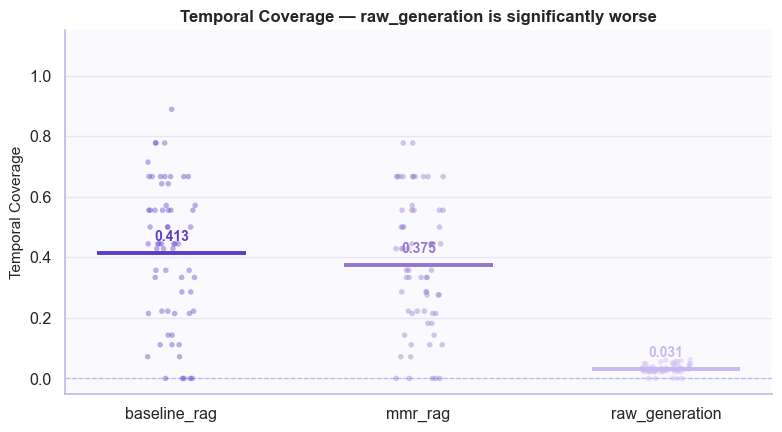

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))

sns.stripplot(
    data=df_rag, x="method", y="temporal_coverage", order=METHODS,
    palette=METHOD_COLORS, alpha=0.4, jitter=True, size=4, ax=ax, zorder=3,
)
for i, method in enumerate(METHODS):
    vals  = df_rag[df_rag["method"] == method]["temporal_coverage"].dropna().values
    color = METHOD_COLORS[method]
    if len(vals):
        mean_val = np.mean(vals)
        ax.hlines(mean_val, i - 0.3, i + 0.3, color=color, linewidth=2.8, zorder=4)
        ax.text(i, mean_val + 0.04, f"{mean_val:.3f}",
                ha="center", fontsize=10, fontweight="bold", color=color)

ax.set_ylabel("Temporal Coverage", fontsize=11)
ax.set_xlabel("")
ax.set_ylim(-0.05, 1.15)
ax.set_title("Temporal Coverage — raw_generation is significantly worse",
             fontsize=12, fontweight="bold")
ax.axhline(0, color="#C4B9EB", linewidth=0.9, linestyle="--")
plt.tight_layout()
plt.show()


C:\Users\alina\AppData\Local\Temp\ipykernel_1568\4147762310.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
C:\Users\alina\AppData\Local\Temp\ipykernel_1568\4147762310.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


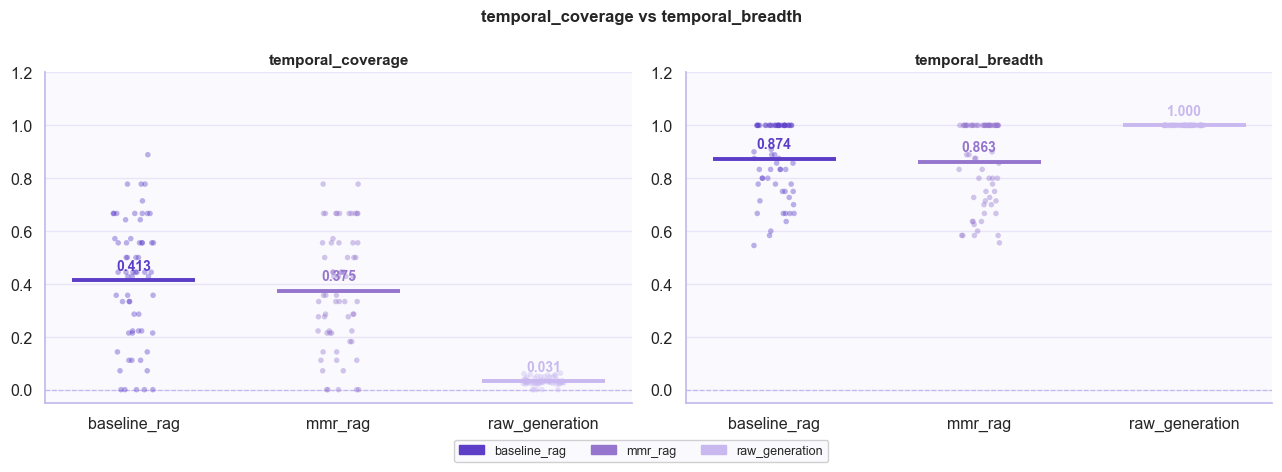


Mean values by method (month + year):
                coverage (uniformity)  breadth (range width)
method                                                      
baseline_rag                   0.4132                 0.8737
mmr_rag                        0.3749                 0.8626
raw_generation                 0.0313                 1.0000


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle(
    "temporal_coverage vs temporal_breadth",
    fontsize=12, fontweight="bold",
)

for ax, (metric, title) in zip(axes, [
    ("temporal_coverage", "temporal_coverage"),
    ("temporal_breadth",  "temporal_breadth"),
]):
    sns.stripplot(
        data=df_rag, x="method", y=metric, order=METHODS,
        palette=METHOD_COLORS, alpha=0.4, jitter=True, size=4, ax=ax, zorder=3,
    )
    for i, method in enumerate(METHODS):
        vals  = df_rag[df_rag["method"] == method][metric].dropna().values
        color = METHOD_COLORS[method]
        if len(vals):
            mean_val = np.mean(vals)
            ax.hlines(mean_val, i - 0.3, i + 0.3, color=color, linewidth=2.8, zorder=4)
            ax.text(i, mean_val + 0.04, f"{mean_val:.3f}",
                    ha="center", fontsize=10, fontweight="bold", color=color)

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_ylim(-0.05, 1.2)
    ax.axhline(0, color="#C4B9EB", linewidth=0.9, linestyle="--")

legend_patches = [mpatches.Patch(color=METHOD_COLORS[m], label=m) for m in METHODS]
fig.legend(handles=legend_patches, loc="lower center", ncol=3, fontsize=9,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.show()

print("\nMean values by method (month + year):")
print(df_rag.groupby("method")[["temporal_coverage", "temporal_breadth"]]
      .mean().round(4).rename(columns={
          "temporal_coverage": "coverage (uniformity)",
          "temporal_breadth":  "breadth (range width)",
      }).to_string())


---
## 3. Δ vs raw_generation — where RAG improves


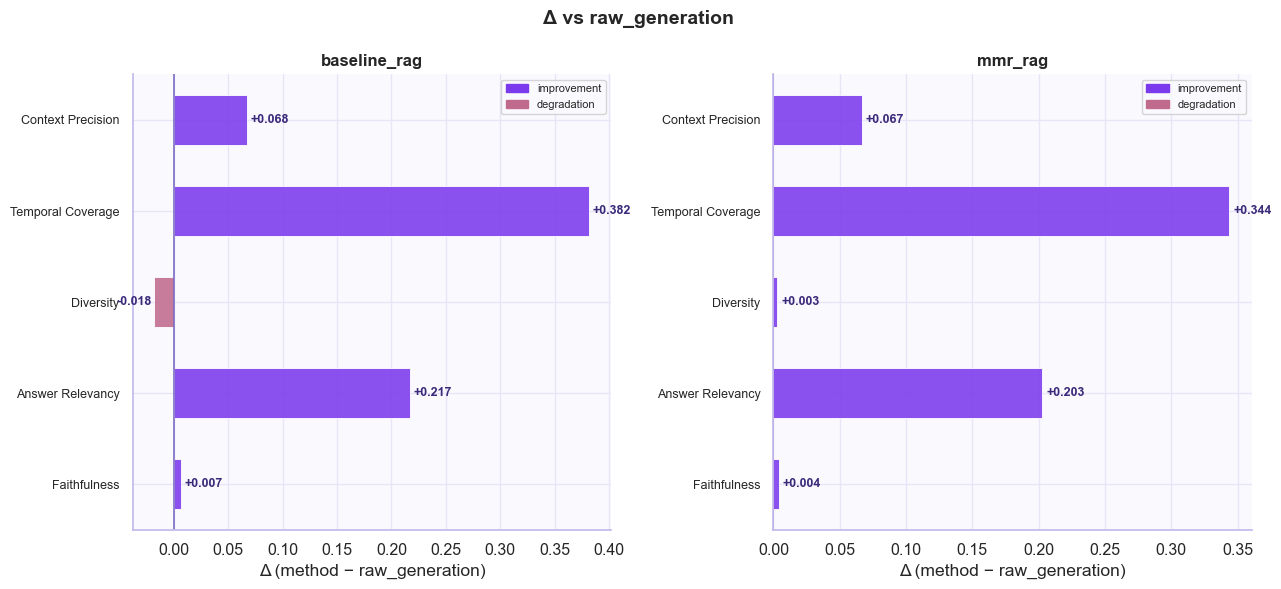

In [9]:
BASELINE = "raw_generation"
compare_methods = [m for m in METHODS if m != BASELINE]

ALL_METRICS = FULL_METRICS + RAG_METRICS
df_month_year = df[df["period_type"].isin(["month", "year"])]
df_all = df

fig, axes = plt.subplots(1, len(compare_methods), figsize=(13, 6))
if len(compare_methods) == 1:
    axes = [axes]
fig.suptitle(f"Δ vs {BASELINE} ",
             fontsize=14, fontweight="bold")

for ax, method in zip(axes, compare_methods):
    deltas, labels = [], []
    for metric in ALL_METRICS:
        subset   = df_month_year if metric in RAG_METRICS else df_all
        base_val = subset[subset["method"] == BASELINE][metric].mean()
        meth_val = subset[subset["method"] == method][metric].mean()
        if pd.isna(base_val) or pd.isna(meth_val):
            continue
        deltas.append(meth_val - base_val)
        labels.append(METRIC_LABELS[metric])

    colors = [PURPLE["positive"] if d >= 0 else PURPLE["negative"] for d in deltas]
    bars = ax.barh(labels, deltas, color=colors, edgecolor="white", linewidth=0.7,
                   alpha=0.88, height=0.55)
    ax.axvline(0, color="#7C6BC4", linewidth=1.2)

    for bar, val in zip(bars, deltas):
        pad = 0.003 if val >= 0 else -0.003
        ha  = "left" if val >= 0 else "right"
        ax.text(val + pad, bar.get_y() + bar.get_height() / 2,
                f"{val:+.3f}", va="center", ha=ha,
                fontsize=9, fontweight="bold", color="#3B2A7A")

    ax.set_title(method, fontsize=12, fontweight="bold")
    ax.set_xlabel(f"Δ (method − {BASELINE})")
    ax.tick_params(axis="y", labelsize=9)

    good = mpatches.Patch(color=PURPLE["positive"], label="improvement")
    bad  = mpatches.Patch(color=PURPLE["negative"], label="degradation")
    ax.legend(handles=[good, bad], fontsize=8, framealpha=0.8)

plt.tight_layout()
plt.show()


---
## 4. Technical Metrics: tokens and generation time


C:\Users\alina\AppData\Local\Temp\ipykernel_1568\1646461575.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\alina\AppData\Local\Temp\ipykernel_1568\1646461575.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\alina\AppData\Local\Temp\ipykernel_1568\1646461575.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\alina\AppData\Local\Temp\ipykernel_1568\1646461575.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

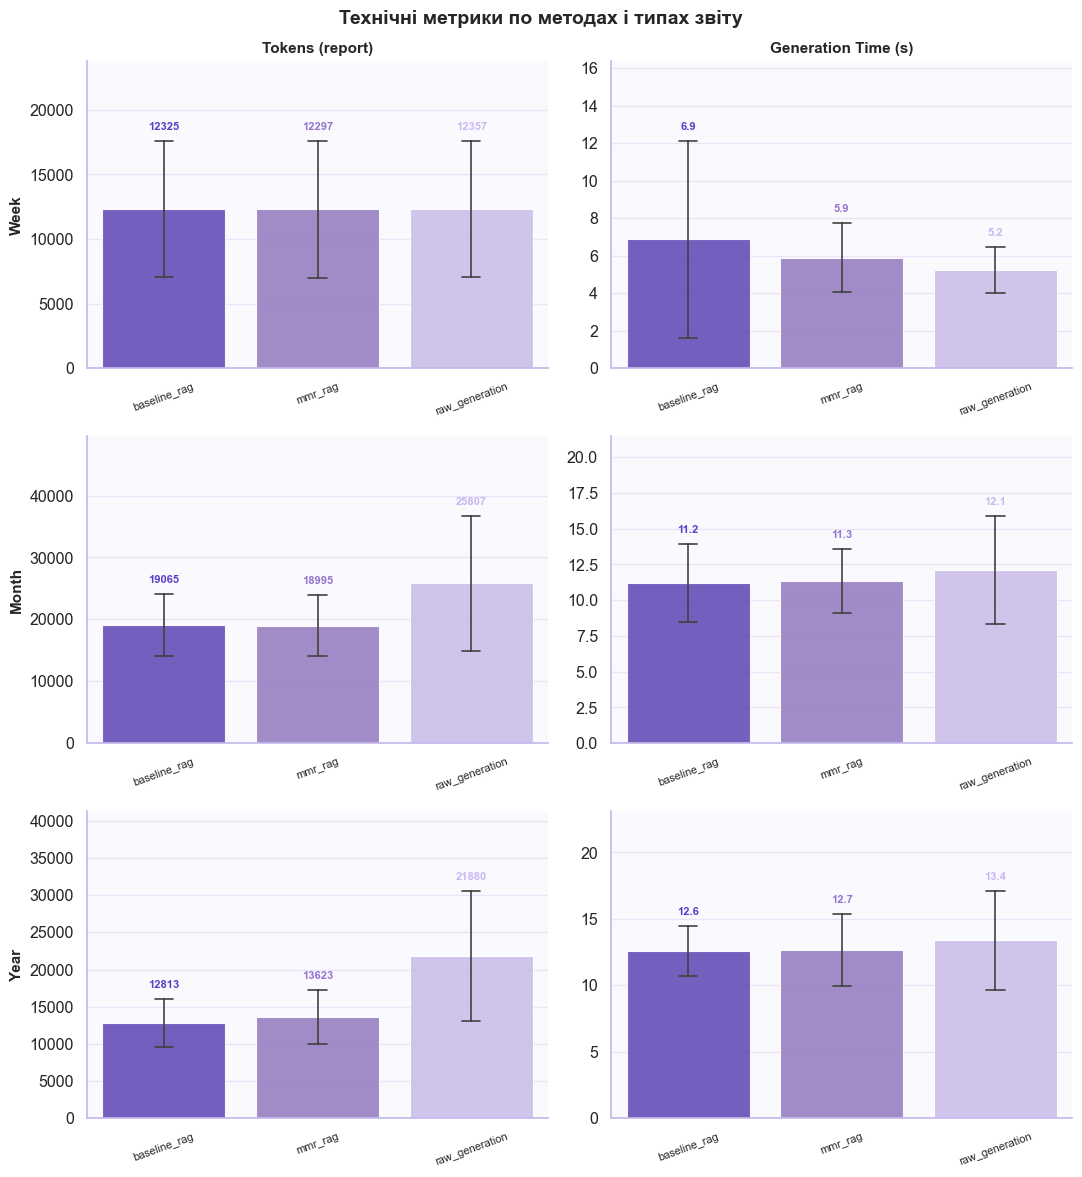

In [10]:
fig, axes = plt.subplots(
    len(PERIOD_ORDER), len(TECH_COLS),
    figsize=(11, 4 * len(PERIOD_ORDER)),
    squeeze=False,
)
fig.suptitle("Технічні метрики по методах і типах звіту", fontsize=14, fontweight="bold")

for r_idx, period in enumerate(PERIOD_ORDER):
    sub = df[df["period_type"] == period]

    for c_idx, col in enumerate(TECH_COLS):
        ax = axes[r_idx][c_idx]

        sns.barplot(
            data=sub, x="method", y=col, order=METHODS,
            palette=METHOD_COLORS, errorbar="sd", capsize=0.12,
            err_kws={"linewidth": 1.2},
            edgecolor="white", linewidth=0.8, alpha=0.9,
            ax=ax,
        )
        means = sub.groupby("method")[col].mean().reindex(METHODS)
        stds  = sub.groupby("method")[col].std().reindex(METHODS).fillna(0)
        tops  = (means + stds).dropna()
        y_max = tops.max() if not tops.empty else 1

        for i, (val, std) in enumerate(zip(means.values, stds.values)):
            if not np.isnan(val):
                label = f"{val:.0f}" if col == "report_tokens_used" else f"{val:.1f}"
                ax.text(i, val + std + y_max * 0.04, label,
                        ha="center", va="bottom", fontsize=8, fontweight="bold",
                        color=METHOD_COLORS[METHODS[i]])

        if r_idx == 0:
            ax.set_title(TECH_LABELS[col], fontsize=11, fontweight="bold")
        if c_idx == 0:
            ax.set_ylabel(PERIOD_LABELS.get(period, period), fontsize=11, fontweight="bold")
        else:
            ax.set_ylabel("")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=20, labelsize=8)
        if y_max:
            ax.set_ylim(0, y_max * 1.35)

plt.tight_layout()
plt.show()

---
## 4.5 Normality Check (justification for Mann-Whitney U)

Mann-Whitney U is non-parametric and does not require normality, but it is good practice to confirm the data is indeed **not normally** distributed before applying it.  
Below — histograms + KDE and the Shapiro-Wilk test for each metric per method.  
**Shapiro-Wilk**: if `p < 0.05` — distribution **deviates from normal** → Mann-Whitney is appropriate.


e:\projects\University\BKR\bcr-app\packages\backend\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


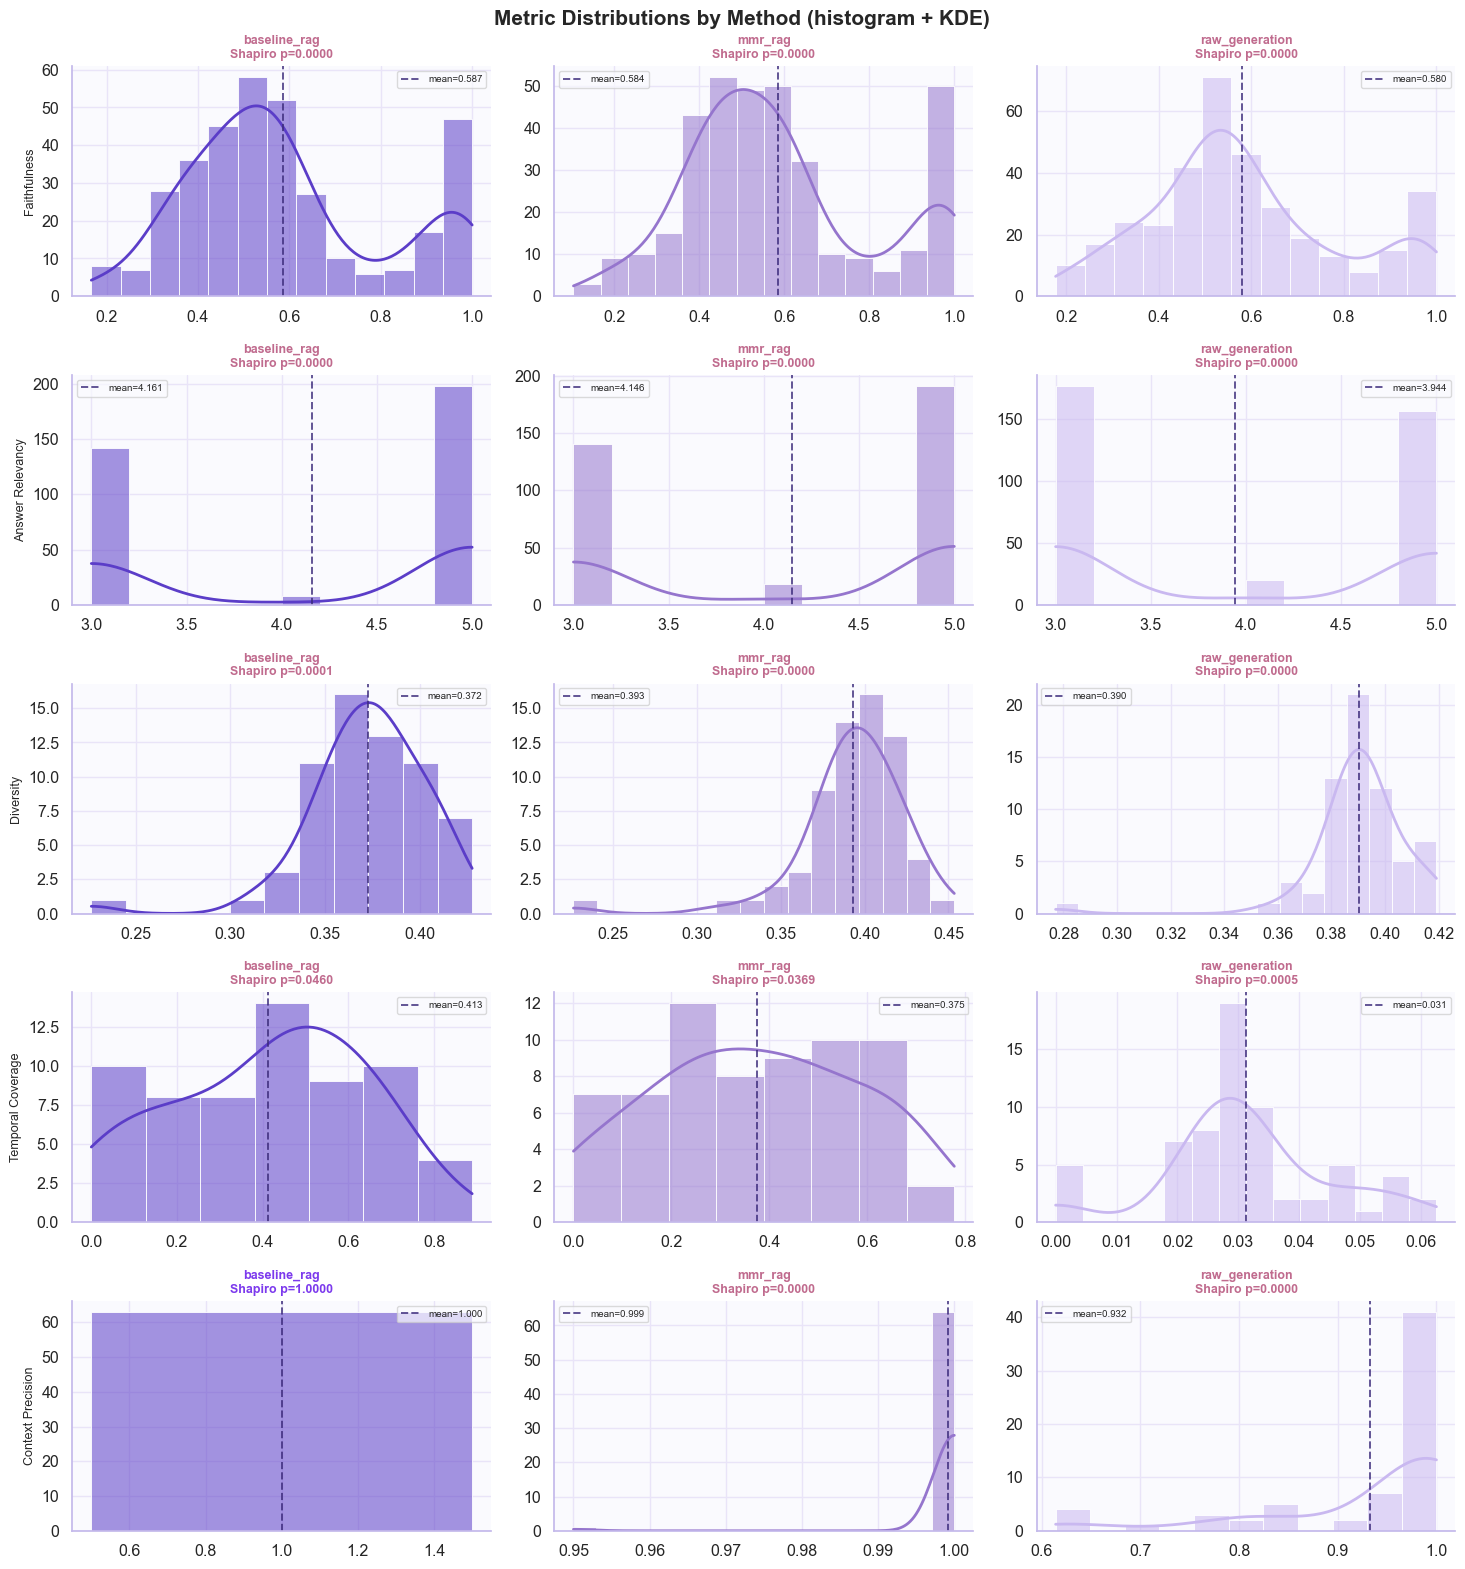

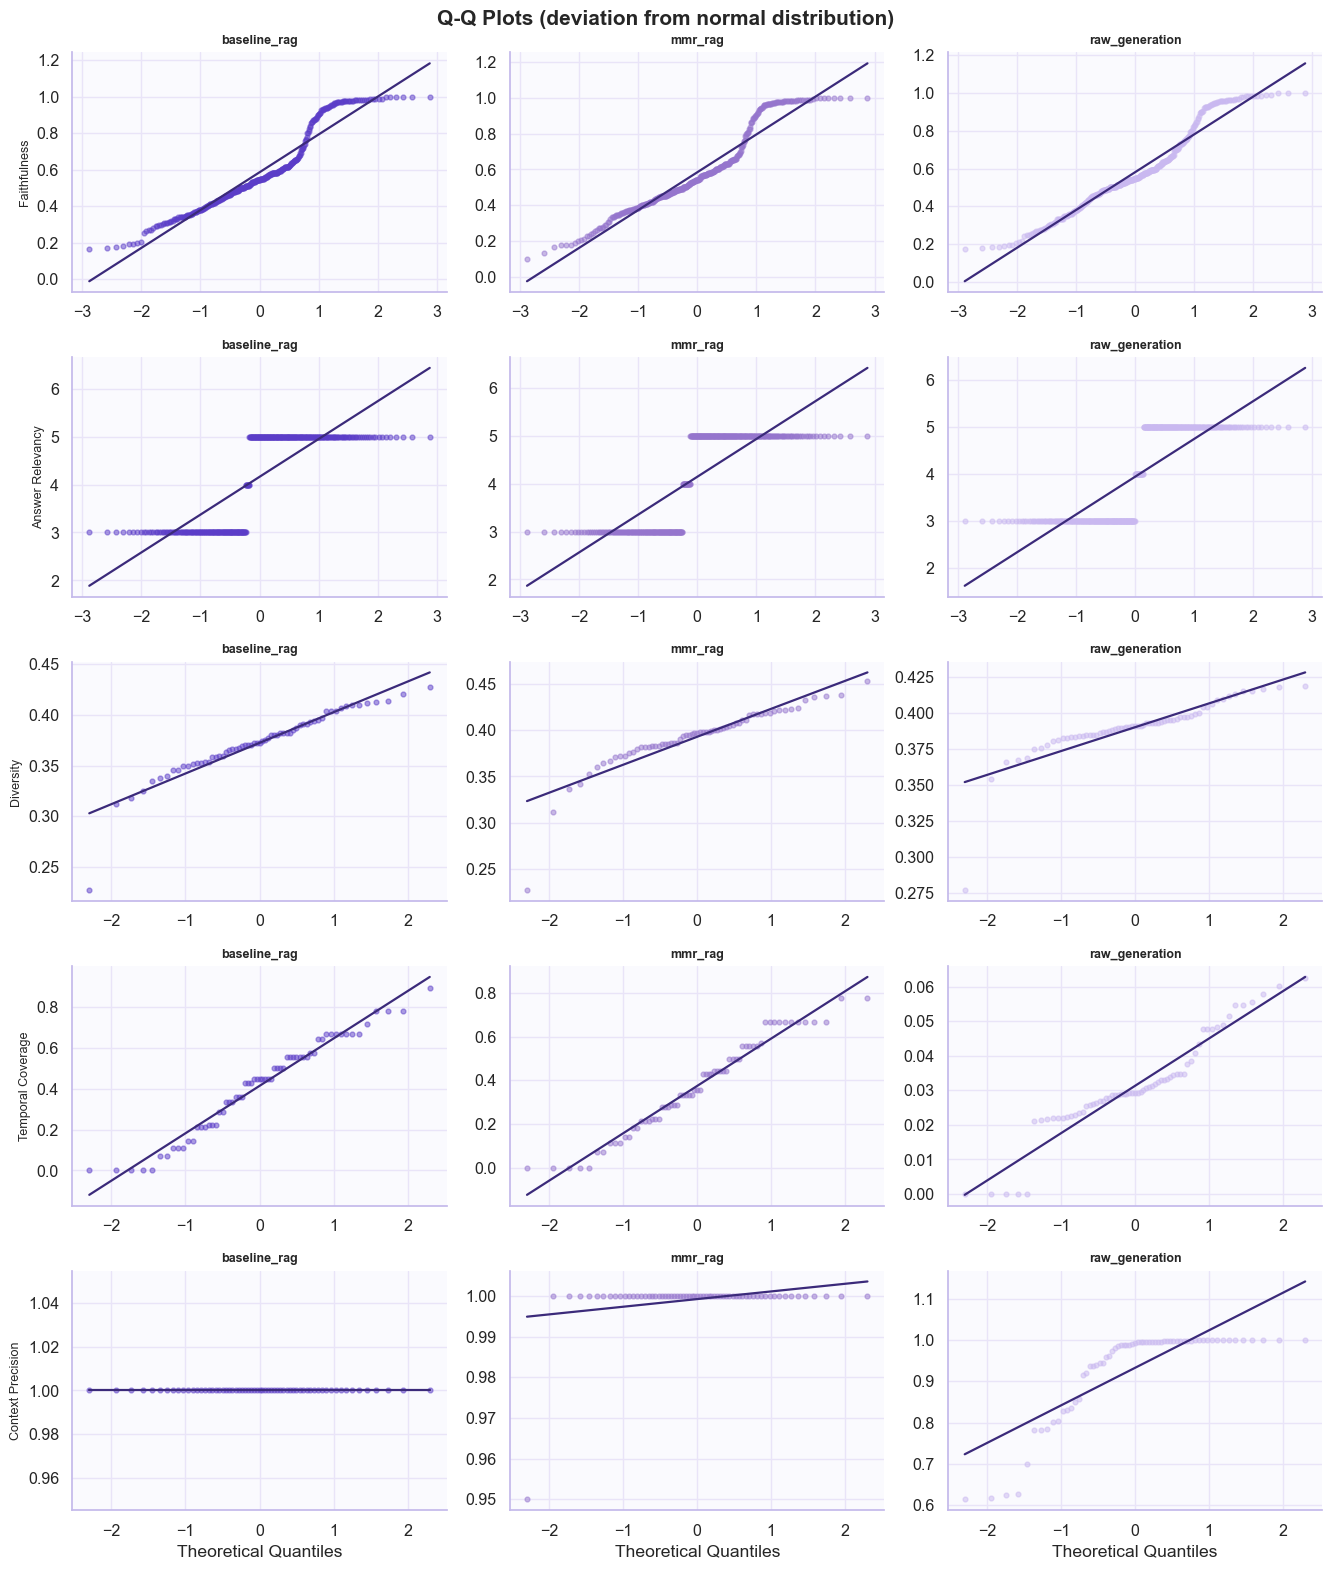


=== Shapiro-Wilk: summary table (p < 0.05 → non-normal → Mann-Whitney appropriate) ===



e:\projects\University\BKR\bcr-app\packages\backend\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


n  W-statistic   p-value       Normal?
Metric            Method                                                  
Faithfulness      baseline_rag    348       0.9259  0.000000   no (p<0.05)
                  mmr_rag         349       0.9308  0.000000   no (p<0.05)
                  raw_generation  351       0.9551  0.000000   no (p<0.05)
Answer Relevancy  baseline_rag    348       0.6416  0.000000   no (p<0.05)
                  mmr_rag         349       0.6608  0.000000   no (p<0.05)
                  raw_generation  354       0.6701  0.000000   no (p<0.05)
Diversity         baseline_rag     63       0.8999  0.000090   no (p<0.05)
                  mmr_rag          65       0.8385  0.000001   no (p<0.05)
                  raw_generation   65       0.7356  0.000000   no (p<0.05)
Temporal Coverage baseline_rag     63       0.9614  0.046035   no (p<0.05)
                  mmr_rag          65       0.9606  0.036861   no (p<0.05)
                  raw_generation   65       0.9210  0.000492   no (p<0.05)
Context Precision baseline_rag     63       1.0000  1.000000  yes (p≥0.05)
                  mmr_rag          65       0.1037  0.000000   no (p<0.05)
                  raw_generation   65       0.6694  0.000000   no (p<0.05)

In [11]:
from scipy.stats import shapiro
from scipy import stats as scipy_stats

ALL_CHECK_METRICS = FULL_METRICS + RAG_METRICS

# ── 1. Histograms + KDE ───────────────────────────────────────────────────────
n_metrics = len(ALL_CHECK_METRICS)
n_methods = len(METHODS)

fig, axes = plt.subplots(
    n_metrics, n_methods,
    figsize=(5 * n_methods, 3.2 * n_metrics),
    squeeze=False,
)
fig.suptitle("Metric Distributions by Method (histogram + KDE)", fontsize=15, fontweight="bold")

for r, metric in enumerate(ALL_CHECK_METRICS):
    subset_df = df_month_year if metric in RAG_METRICS else df
    for c, method in enumerate(METHODS):
        ax = axes[r][c]
        vals = subset_df[subset_df["method"] == method][metric].dropna().values

        if len(vals) < 4:
            ax.text(0.5, 0.5, "too few data points", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10, color="gray")
        else:
            sns.histplot(vals, kde=True, ax=ax,
                         color=METHOD_COLORS[method], alpha=0.55,
                         edgecolor="white", linewidth=0.6,
                         line_kws={"linewidth": 2})
            stat, p = shapiro(vals[:5000])  # Shapiro limited to 5000
            color_p = PURPLE["negative"] if p < 0.05 else PURPLE["positive"]
            ax.set_title(
                f"{method}\nShapiro p={p:.4f}",
                fontsize=9, fontweight="bold", color=color_p,
            )
            ax.axvline(np.mean(vals), color="#3B2A7A", linewidth=1.4,
                       linestyle="--", alpha=0.8, label=f"mean={np.mean(vals):.3f}")
            ax.legend(fontsize=7, framealpha=0.7)

        if c == 0:
            ax.set_ylabel(METRIC_LABELS.get(metric, metric), fontsize=9)
        else:
            ax.set_ylabel("")
        ax.set_xlabel("")

plt.tight_layout()
plt.show()

# ── 2. Q-Q plots ──────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(
    n_metrics, n_methods,
    figsize=(4.5 * n_methods, 3.2 * n_metrics),
    squeeze=False,
)
fig2.suptitle("Q-Q Plots (deviation from normal distribution)", fontsize=15, fontweight="bold")

for r, metric in enumerate(ALL_CHECK_METRICS):
    subset_df = df_month_year if metric in RAG_METRICS else df
    for c, method in enumerate(METHODS):
        ax = axes2[r][c]
        vals = subset_df[subset_df["method"] == method][metric].dropna().values

        if len(vals) < 4:
            ax.text(0.5, 0.5, "too few data points", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10, color="gray")
        else:
            (osm, osr), (slope, intercept, _) = scipy_stats.probplot(vals, dist="norm")
            ax.scatter(osm, osr, color=METHOD_COLORS[method], alpha=0.5, s=12, zorder=3)
            x_line = np.array([osm.min(), osm.max()])
            ax.plot(x_line, slope * x_line + intercept,
                    color="#3B2A7A", linewidth=1.6, zorder=4)
            ax.set_title(f"{method}", fontsize=9, fontweight="bold")

        if c == 0:
            ax.set_ylabel(METRIC_LABELS.get(metric, metric), fontsize=9)
        else:
            ax.set_ylabel("")
        ax.set_xlabel("Theoretical Quantiles" if r == n_metrics - 1 else "")

plt.tight_layout()
plt.show()

# ── 3. Shapiro-Wilk summary table ─────────────────────────────────────────────
print("\n=== Shapiro-Wilk: summary table (p < 0.05 → non-normal → Mann-Whitney appropriate) ===\n")
rows_sw = []
for metric in ALL_CHECK_METRICS:
    subset_df = df_month_year if metric in RAG_METRICS else df
    for method in METHODS:
        vals = subset_df[subset_df["method"] == method][metric].dropna().values
        if len(vals) < 4:
            rows_sw.append({"Metric": METRIC_LABELS.get(metric, metric),
                             "Method": method, "n": len(vals),
                             "W-statistic": None, "p-value": None,
                             "Normal?": "too few data points"})
        else:
            stat, p = shapiro(vals[:5000])
            rows_sw.append({"Metric": METRIC_LABELS.get(metric, metric),
                             "Method": method, "n": len(vals),
                             "W-statistic": round(stat, 4),
                             "p-value": round(p, 6),
                             "Normal?": "no (p<0.05)" if p < 0.05 else "yes (p≥0.05)"})

sw_df = pd.DataFrame(rows_sw).set_index(["Metric", "Method"])
display(sw_df)


---
## 5. Statistical Significance (Mann-Whitney U)

`p < 0.05` — difference is statistically significant; `p ≥ 0.05` — may be random noise.


In [12]:
def run_mwu(subset, metrics, methods):
    rows = []
    for m1, m2 in combinations(methods, 2):
        for metric in metrics:
            a = subset[subset["method"] == m1][metric].dropna().values
            b = subset[subset["method"] == m2][metric].dropna().values
            if len(a) < 3 or len(b) < 3:
                rows.append({
                    "Pair": f"{m1} vs {m2}",
                    "Metric": METRIC_LABELS.get(metric, metric),
                    "n1": len(a), "n2": len(b),
                    "mean1": round(a.mean(), 4) if len(a) else None,
                    "mean2": round(b.mean(), 4) if len(b) else None,
                    "p-value": None,
                    "Significant?": "too few data points",
                })
                continue
            _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
            rows.append({
                "Pair": f"{m1} vs {m2}",
                "Metric": METRIC_LABELS.get(metric, metric),
                "n1": len(a), "n2": len(b),
                "mean1": round(a.mean(), 4),
                "mean2": round(b.mean(), 4),
                "p-value": round(p, 4),
                "Significant?": "yes" if p < 0.05 else "no",
            })
    return pd.DataFrame(rows).set_index(["Pair", "Metric"])

# Common metrics — all data
print("=== Common metrics (faithfulness + relevancy) — all periods ===")
display(run_mwu(df, FULL_METRICS, METHODS))

# RAG metrics — month + year only
print("\n=== RAG metrics (month + year) ===")
display(run_mwu(df_month_year, RAG_METRICS, METHODS))


=== Common metrics (faithfulness + relevancy) — all periods ===


n1   n2   mean1   mean2  \
Pair                           Metric                                       
baseline_rag vs mmr_rag        Faithfulness      348  349  0.5868  0.5841   
                               Answer Relevancy  348  349  4.1609  4.1461   
baseline_rag vs raw_generation Faithfulness      348  351  0.5868  0.5802   
                               Answer Relevancy  348  354  4.1609  3.9435   
mmr_rag vs raw_generation      Faithfulness      349  351  0.5841  0.5802   
                               Answer Relevancy  349  354  4.1461  3.9435   

                                                 p-value Significant?  
Pair                           Metric                                  
baseline_rag vs mmr_rag        Faithfulness       0.9607           no  
                               Answer Relevancy   0.7962           no  
baseline_rag vs raw_generation Faithfulness       0.9488           no  
                               Answer Relevancy   0.0030          yes  
mmr_rag vs raw_generation      Faithfulness       0.8257           no  
                               Answer Relevancy   0.0057          yes


=== RAG metrics (month + year) ===


n1  n2   mean1   mean2  \
Pair                           Metric                                      
baseline_rag vs mmr_rag        Diversity          63  65  0.3724  0.3930   
                               Temporal Coverage  63  65  0.4132  0.3749   
                               Context Precision  63  65  1.0000  0.9992   
baseline_rag vs raw_generation Diversity          63  65  0.3724  0.3903   
                               Temporal Coverage  63  65  0.4132  0.0313   
                               Context Precision  63  65  1.0000  0.9325   
mmr_rag vs raw_generation      Diversity          65  65  0.3930  0.3903   
                               Temporal Coverage  65  65  0.3749  0.0313   
                               Context Precision  65  65  0.9992  0.9325   

                                                  p-value Significant?  
Pair                           Metric                                   
baseline_rag vs mmr_rag        Diversity           0.0000          yes  
                               Temporal Coverage   0.3086           no  
                               Context Precision   0.3326           no  
baseline_rag vs raw_generation Diversity           0.0000          yes  
                               Temporal Coverage   0.0000          yes  
                               Context Precision   0.0000          yes  
mmr_rag vs raw_generation      Diversity           0.1653           no  
                               Temporal Coverage   0.0000          yes  
                               Context Precision   0.0000          yes

---
## 6. Summary Table of Mean Values


In [13]:
summary = df.groupby("method")[FULL_METRICS + TECH_COLS].mean().round(4)
summary.columns = [
    METRIC_LABELS.get(c, TECH_LABELS.get(c, c))
    for c in FULL_METRICS + TECH_COLS
]

rag_summary = df_month_year.groupby("method")[RAG_METRICS].mean().round(4)
rag_summary.columns = [METRIC_LABELS[c] for c in RAG_METRICS]

full_summary = summary.join(rag_summary)
display(
    full_summary.style
    .background_gradient(cmap="BuPu", axis=0)
    .format("{:.4f}")
    .set_caption("Mean metric values by method (RAG metrics: month+year only)")
)


,Faithfulness,Answer Relevancy,Tokens (report),Generation Time (s),Diversity,Temporal Coverage,Context Precision
method,,,,,,,
baseline_rag,0.5868,4.1609,13559.4856,7.8302,0.3724,0.4132,1.0000
mmr_rag,0.5841,4.1461,13582.3610,7.1005,0.3930,0.3749,0.9992
raw_generation,0.5802,3.9435,15095.8475,6.7225,0.3903,0.0313,0.9325


---
## 7. MMR RAG: Comparison by Report Language (Ukrainian vs English)

Language is detected automatically by the number of Cyrillic characters in the report text.  
**Ukrainian**: user_id 21, 23, 25 — **English**: user_id 22, 24.


In [14]:
# Load MMR separately (with generated_text for language detection)
mmr_raw = pd.read_csv(EXPERIMENTS / "results_mmr_rag.csv", encoding="utf-8")

def detect_lang(text):
    if pd.isna(text):
        return "unknown"
    cyrillic = len(re.findall(r"[а-яіїєёА-ЯІЇЄЁ]", str(text)[:500]))
    return "Ukrainian" if cyrillic > 5 else "English"

mmr_raw["language"] = mmr_raw["generated_text"].apply(detect_lang)
mmr_raw = mmr_raw.rename(columns={"user_id": "userId"})

for col in METRIC_COLS + TECH_COLS:
    mmr_raw[col] = pd.to_numeric(mmr_raw[col], errors="coerce")

lang_counts = mmr_raw.groupby(["language", "period_type"]).size().rename("n")
print("Distribution by language and report type:")
print(lang_counts.to_string())
print()
print("Total: Ukrainian =", (mmr_raw["language"] == "Ukrainian").sum(),
      " | English =", (mmr_raw["language"] == "English").sum())


Distribution by language and report type:
language   period_type
English    month           26
           week           109
           year             5
Ukrainian  month           39
           week           165
           year             5

Total: Ukrainian = 209  | English = 140


C:\Users\alina\AppData\Local\Temp\ipykernel_1568\1723832265.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\alina\AppData\Local\Temp\ipykernel_1568\1723832265.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
C:\Users\alina\AppData\Local\Temp\ipykernel_1568\1723832265.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\alina\AppData\Local\Temp\ipykernel_1568\1723832265.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

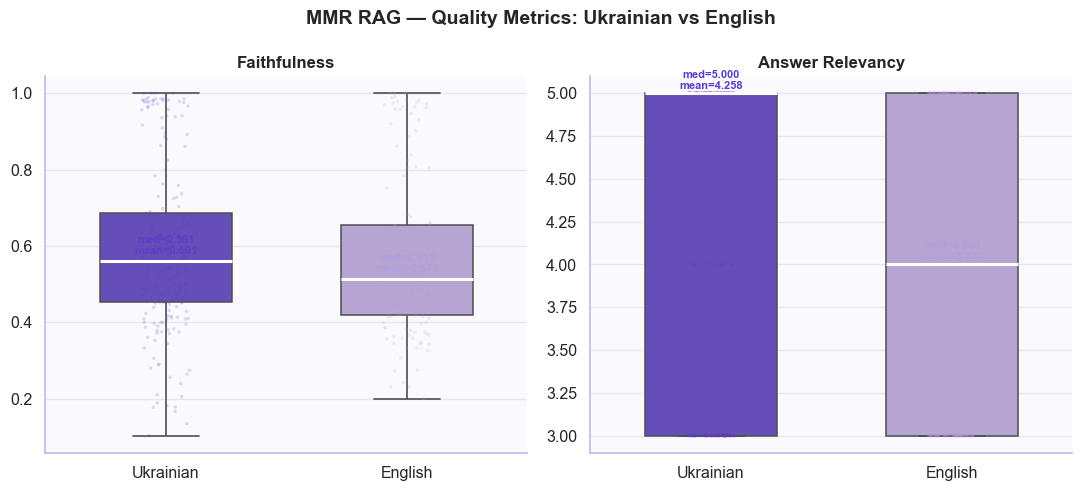

In [15]:
LANGS = ["Ukrainian", "English"]
FULL_METRICS = ["faithfulness_report", "answer_relevancy_report"]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle("MMR RAG — Quality Metrics: Ukrainian vs English",
             fontsize=14, fontweight="bold")

for ax, metric in zip(axes, FULL_METRICS):
    sns.boxplot(
        data=mmr_raw, x="language", y=metric, order=LANGS,
        palette=LANG_COLORS, linewidth=1.1, width=0.55,
        medianprops={"color": "white", "linewidth": 2.2},
        whiskerprops={"linewidth": 1.2},
        capprops={"linewidth": 1.2},
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.35, "markeredgewidth": 0},
        ax=ax,
    )
    sns.stripplot(
        data=mmr_raw, x="language", y=metric, order=LANGS,
        palette=LANG_COLORS, alpha=0.18, jitter=True, size=2.5,
        ax=ax, zorder=2,
    )
    for i, lang in enumerate(LANGS):
        vals = mmr_raw[mmr_raw["language"] == lang][metric].dropna().values
        if len(vals):
            med  = np.median(vals)
            mean = np.mean(vals)
            ax.text(i, med + 0.012, f"med={med:.3f}\nmean={mean:.3f}",
                    ha="center", va="bottom", fontsize=8, fontweight="bold",
                    color=LANG_COLORS[lang])

    ax.set_title(METRIC_LABELS[metric], fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


C:\Users\alina\AppData\Local\Temp\ipykernel_1568\2728624057.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\alina\AppData\Local\Temp\ipykernel_1568\2728624057.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\alina\AppData\Local\Temp\ipykernel_1568\2728624057.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


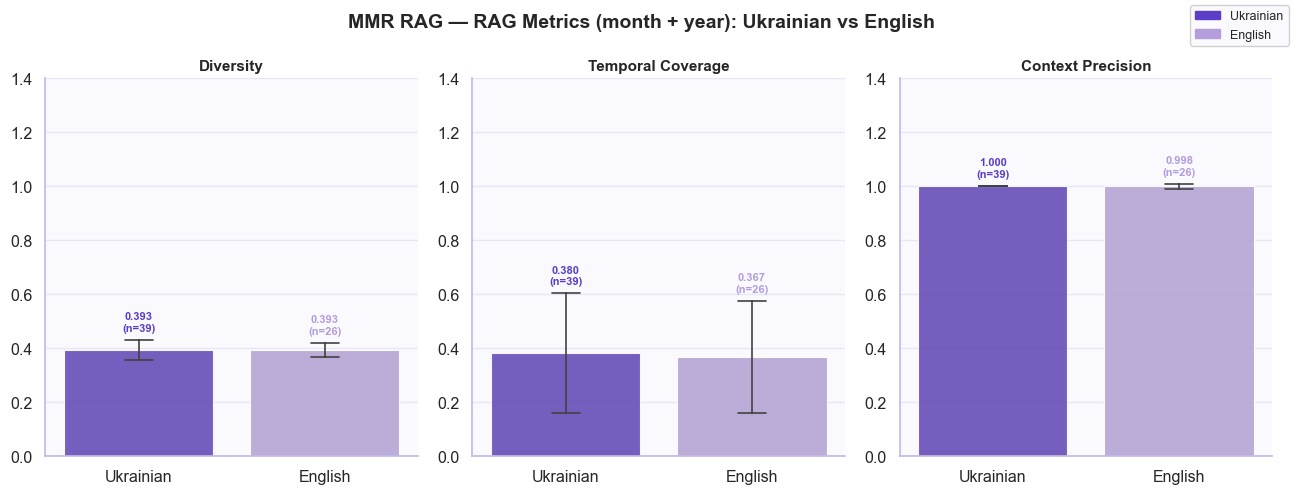

In [16]:
RAG_METRICS = ["diversity", "temporal_coverage", "context_precision"]
mmr_month_year = mmr_raw[mmr_raw["period_type"].isin(["month", "year"])]

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle("MMR RAG — RAG Metrics (month + year): Ukrainian vs English",
             fontsize=14, fontweight="bold")

for ax, metric in zip(axes, RAG_METRICS):
    sns.barplot(
        data=mmr_month_year, x="language", y=metric, order=LANGS,
        palette=LANG_COLORS, errorbar="sd", capsize=0.15,
        err_kws={"linewidth": 1.2},
        edgecolor="white", linewidth=0.8, alpha=0.9,
        ax=ax,
    )
    means = mmr_month_year.groupby("language")[metric].mean().reindex(LANGS)
    stds  = mmr_month_year.groupby("language")[metric].std().reindex(LANGS).fillna(0)
    ns    = mmr_month_year.groupby("language")[metric].count().reindex(LANGS)
    for i, (val, std, n) in enumerate(zip(means.values, stds.values, ns.values)):
        if not np.isnan(val):
            ax.text(i, val + std + 0.025, f"{val:.3f}\n(n={n})",
                    ha="center", va="bottom", fontsize=8, fontweight="bold",
                    color=LANG_COLORS[LANGS[i]])

    ax.set_title(METRIC_LABELS[metric], fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_ylim(0, 1.4)

legend_patches = [mpatches.Patch(color=LANG_COLORS[l], label=l) for l in LANGS]
fig.legend(handles=legend_patches, loc="upper right", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()


C:\Users\alina\AppData\Local\Temp\ipykernel_1568\735034376.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\alina\AppData\Local\Temp\ipykernel_1568\735034376.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\alina\AppData\Local\Temp\ipykernel_1568\735034376.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\alina\AppData\Local\Temp\ipykernel_1568\735034376.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set 

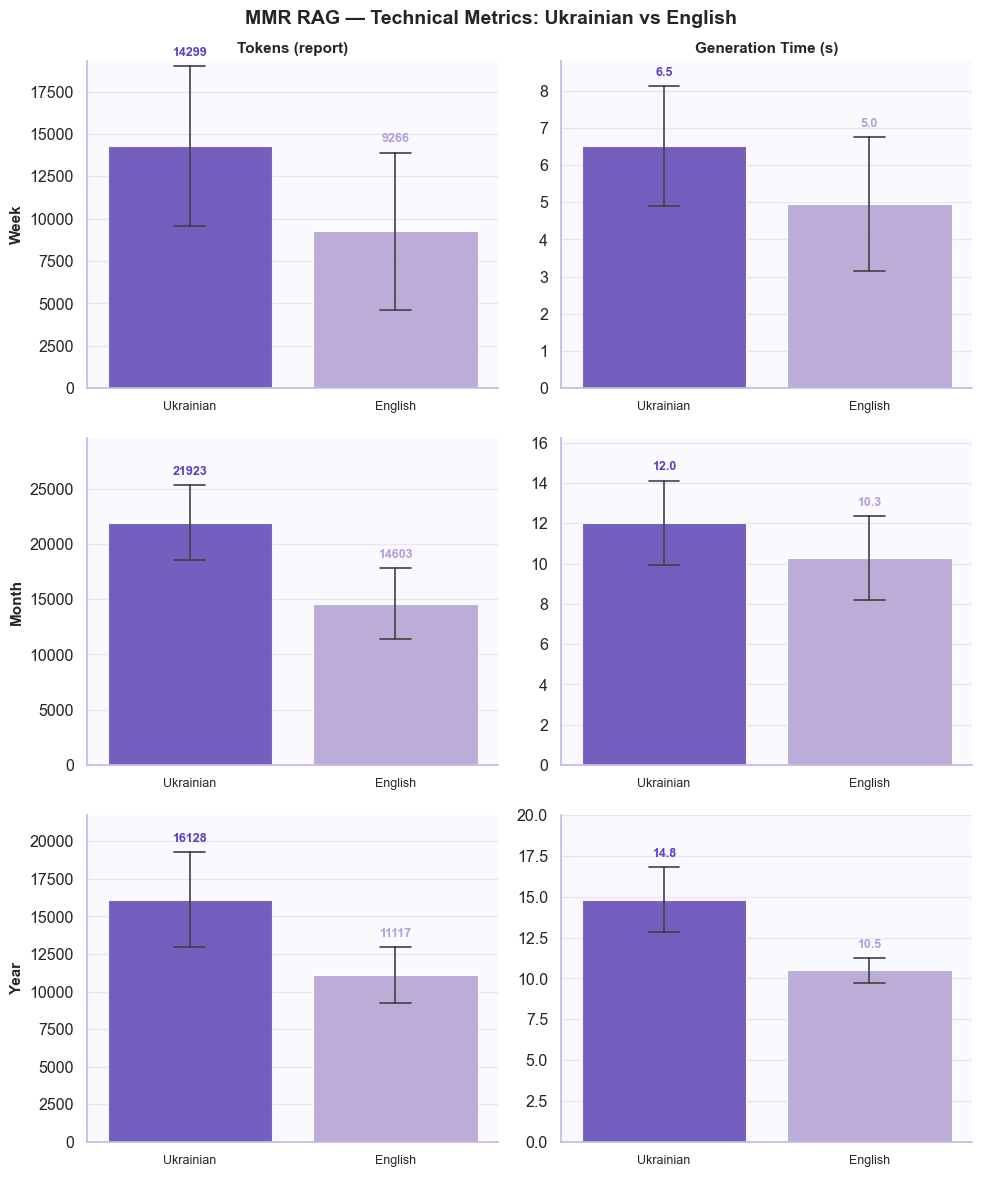

In [17]:
fig, axes = plt.subplots(len(PERIOD_ORDER), 2, figsize=(10, 4 * len(PERIOD_ORDER)), squeeze=False)
fig.suptitle("MMR RAG — Technical Metrics: Ukrainian vs English", fontsize=14, fontweight="bold")

for r_idx, period in enumerate(PERIOD_ORDER):
    sub = mmr_raw[mmr_raw["period_type"] == period]
    for c_idx, col in enumerate(TECH_COLS):
        ax = axes[r_idx][c_idx]

        sns.barplot(
            data=sub, x="language", y=col, order=LANGS,
            palette=LANG_COLORS, errorbar="sd", capsize=0.15,
            err_kws={"linewidth": 1.2},
            edgecolor="white", linewidth=0.8, alpha=0.9,
            ax=ax,
        )
        means = sub.groupby("language")[col].mean().reindex(LANGS)
        stds  = sub.groupby("language")[col].std().reindex(LANGS).fillna(0)
        top   = means.dropna().max() if not means.dropna().empty else 1
        for i, (val, std) in enumerate(zip(means.values, stds.values)):
            if not np.isnan(val):
                label = f"{val:.0f}" if col == "report_tokens_used" else f"{val:.1f}"
                ax.text(i, val + std + top * 0.03, label,
                        ha="center", va="bottom", fontsize=9, fontweight="bold",
                        color=LANG_COLORS[LANGS[i]])

        if r_idx == 0:
            ax.set_title(TECH_LABELS[col], fontsize=11, fontweight="bold")
        if c_idx == 0:
            ax.set_ylabel(PERIOD_LABELS.get(period, period), fontsize=11, fontweight="bold")
        else:
            ax.set_ylabel("")
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelsize=9)
        valid = means.dropna().values
        if len(valid):
            ax.set_ylim(0, max(valid) * 1.35)

plt.tight_layout()
plt.show()


In [18]:
# Statistical significance: Mann-Whitney U for Ukrainian vs English in MMR
print("=== Mann-Whitney U: Ukrainian vs English (MMR RAG) ===\n")

rows = []
test_metrics = {
    "all":        (mmr_raw,        FULL_METRICS),
    "month+year": (mmr_month_year, RAG_METRICS + TECH_COLS),
}
for subset_name, (subset, metrics) in test_metrics.items():
    for metric in metrics:
        a = subset[subset["language"] == "Ukrainian"][metric].dropna().values
        b = subset[subset["language"] == "English"][metric].dropna().values
        if len(a) < 3 or len(b) < 3:
            sig = "⚠️ too few data points"
            p = None
        else:
            _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
            sig = "✅ yes" if p < 0.05 else "❌ no"
        rows.append({
            "Data": subset_name,
            "Metric": METRIC_LABELS.get(metric, TECH_LABELS.get(metric, metric)),
            "n (UK)": len(a), "n (EN)": len(b),
            "mean (UK)": round(a.mean(), 4) if len(a) else None,
            "mean (EN)": round(b.mean(), 4) if len(b) else None,
            "p-value": round(p, 4) if p is not None else None,
            "Significant?": sig,
        })

result_df = pd.DataFrame(rows).set_index(["Data", "Metric"])
display(result_df)


=== Mann-Whitney U: Ukrainian vs English (MMR RAG) ===



n (UK)  n (EN)   mean (UK)   mean (EN)  \
Data       Metric                                                        
all        Faithfulness            209     140      0.5909      0.5741   
           Answer Relevancy        209     140      4.2584      3.9786   
month+year Diversity                39      26      0.3929      0.3933   
           Temporal Coverage        39      26      0.3802      0.3668   
           Context Precision        39      26      1.0000      0.9981   
           Tokens (report)          44      31  21264.9091  14040.5161   
           Generation Time (s)      44      31     12.3489     10.3114   

                                p-value Significant?  
Data       Metric                                     
all        Faithfulness          0.1906         ❌ no  
           Answer Relevancy      0.0081        ✅ yes  
month+year Diversity             1.0000         ❌ no  
           Temporal Coverage     0.8508         ❌ no  
           Context Precision     0.2327         ❌ no  
           Tokens (report)       0.0000        ✅ yes  
           Generation Time (s)   0.0000        ✅ yes

---
## 8. Tokens vs Data Growth (single user, monthly reports)

RAG uses a **stable** number of tokens regardless of accumulated history (always top-k chunks).  
`raw_generation` passes **all** previous records — tokens grow linearly with each new month.


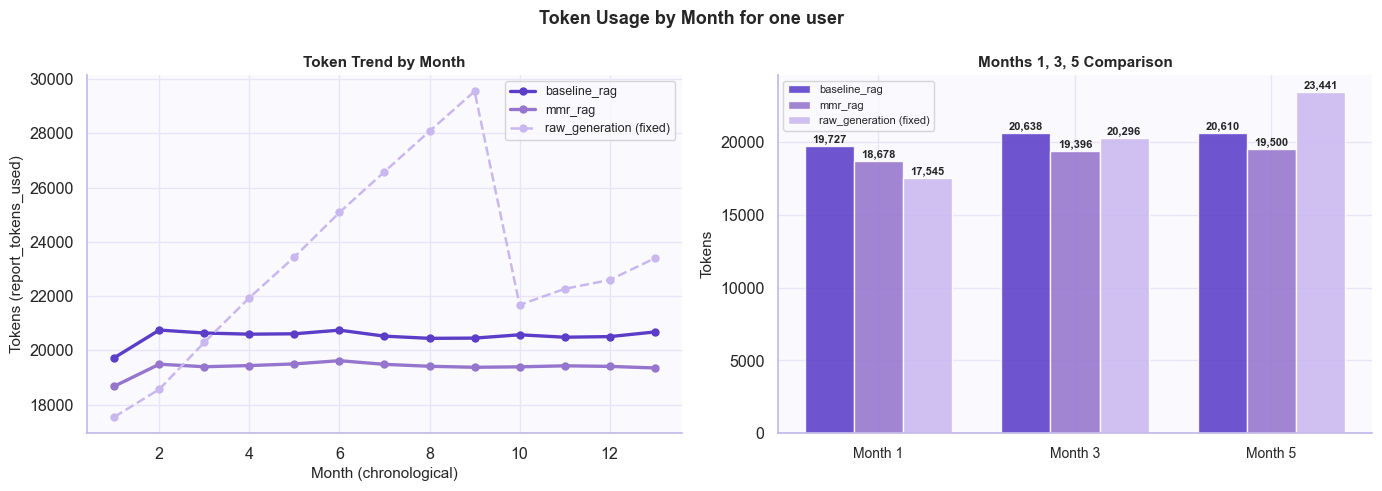


Tokens for user (months 1, 3, 5):


,Month 1,Month 3,Month 5
baseline_rag,19727,20638,20610
mmr_rag,18678,19396,19500
raw_generation (fixed),17545,20296,23441


In [19]:
from pathlib import Path

df_month = df[df["period_type"] == "month"].copy()
df_month["period_start"] = pd.to_datetime(df_month["period_start"])

# Select user with most months in raw_generation
user_month_counts = (
    df_month[df_month["method"] == "raw_generation"]
    .groupby("userId")["period_start"].count()
)
selected_user = user_month_counts.idxmax()

# RAG methods — from main df
dfs_user = {}
for method in ["baseline_rag", "mmr_rag"]:
    sub = (
        df_month[(df_month["method"] == method) & (df_month["userId"] == selected_user)]
        .copy()
        .sort_values("period_start")
        .reset_index(drop=True)
    )
    sub["month_num"] = range(1, len(sub) + 1)
    dfs_user[method] = sub

# raw_generation — use corrected CSV if available, otherwise original
corrected_path = EXPERIMENTS / "results_raw_generation_corrected.csv"
if corrected_path.exists():
    df_raw_fixed = pd.read_csv(corrected_path)
    df_raw_fixed["period_start"] = pd.to_datetime(df_raw_fixed["period_start"])
    df_raw_fixed = df_raw_fixed.sort_values("period_start").reset_index(drop=True)
    df_raw_fixed["month_num"] = range(1, len(df_raw_fixed) + 1)
    # normalize token column name
    if "tokens_used" not in df_raw_fixed.columns and "report_tokens_used" in df_raw_fixed.columns:
        df_raw_fixed = df_raw_fixed.rename(columns={"report_tokens_used": "tokens_used"})
    raw_label = "raw_generation (fixed)"
else:
    sub = (
        df_month[(df_month["method"] == "raw_generation") & (df_month["userId"] == selected_user)]
        .copy()
        .sort_values("period_start")
        .reset_index(drop=True)
    )
    sub["month_num"] = range(1, len(sub) + 1)
    sub = sub.rename(columns={"report_tokens_used": "tokens_used"})
    df_raw_fixed = sub
    raw_label = "raw_generation (bug — full context)"
    print("Fixed CSV not found — showing old data with bug")

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"Token Usage by Month for one user",
    fontsize=13, fontweight="bold",
)

# Line chart — RAG methods
for method, sub in dfs_user.items():
    ax1.plot(
        sub["month_num"], sub["report_tokens_used"],
        color=METHOD_COLORS[method], linewidth=2.4, linestyle="-",
        marker="o", markersize=5, label=method,
    )

# raw_generation (fixed or original)
ax1.plot(
    df_raw_fixed["month_num"], df_raw_fixed["tokens_used"],
    color=METHOD_COLORS["raw_generation"], linewidth=1.8, linestyle="--",
    marker="o", markersize=5, label=raw_label,
)

ax1.set_xlabel("Month (chronological)", fontsize=11)
ax1.set_ylabel("Tokens (report_tokens_used)", fontsize=11)
ax1.set_title("Token Trend by Month", fontsize=11, fontweight="bold")
ax1.legend(fontsize=9)
ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Bar chart — months 1, 3, 5
target_months = [1, 3, 5]

bar_data = {}
for method, sub in dfs_user.items():
    bar_data[method] = [
        sub.loc[sub["month_num"] == mn, "report_tokens_used"].values[0]
        if (sub["month_num"] == mn).any() else np.nan
        for mn in target_months
    ]
bar_data[raw_label] = [
    df_raw_fixed.loc[df_raw_fixed["month_num"] == mn, "tokens_used"].values[0]
    if (df_raw_fixed["month_num"] == mn).any() else np.nan
    for mn in target_months
]

colors_bar = [METHOD_COLORS["baseline_rag"], METHOD_COLORS["mmr_rag"], METHOD_COLORS["raw_generation"]]
x = np.arange(len(target_months))
width = 0.25
for i, (method, vals) in enumerate(bar_data.items()):
    bars = ax2.bar(
        x + i * width, vals, width,
        label=method, color=colors_bar[i], edgecolor="white", alpha=0.88,
    )
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax2.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height() + 150,
                f"{int(val):,}", ha="center", va="bottom", fontsize=8, fontweight="bold",
            )

ax2.set_xticks(x + width)
ax2.set_xticklabels([f"Month {mn}" for mn in target_months], fontsize=10)
ax2.set_ylabel("Tokens", fontsize=11)
ax2.set_title("Months 1, 3, 5 Comparison", fontsize=11, fontweight="bold")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Table ──────────────────────────────────────────────────────────────────────
print(f"\nTokens for user (months 1, 3, 5):")
table = pd.DataFrame(
    {method: {f"Month {mn}": int(v) if not np.isnan(v) else "-"
              for mn, v in zip(target_months, vals)}
     for method, vals in bar_data.items()}
).T
display(table)


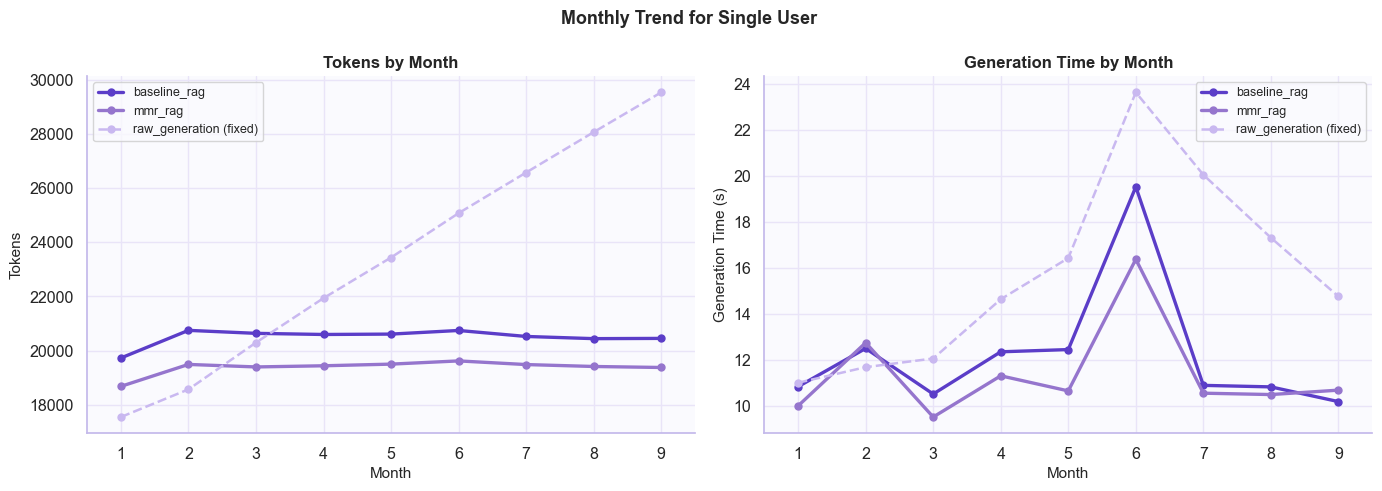

In [20]:
# Token and generation time trend by month (up to month 9)
MAX_MONTH = 9

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"Monthly Trend for Single User ",
    fontsize=13, fontweight="bold",
)

for method, sub in dfs_user.items():
    sub_cut = sub[sub["month_num"] <= MAX_MONTH]
    ax1.plot(
        sub_cut["month_num"], sub_cut["report_tokens_used"],
        color=METHOD_COLORS[method], linewidth=2.4, linestyle="-",
        marker="o", markersize=5, label=method,
    )
    time_col = "report_generation_time" if "report_generation_time" in sub_cut.columns else None
    if time_col:
        ax2.plot(
            sub_cut["month_num"], sub_cut[time_col],
            color=METHOD_COLORS[method], linewidth=2.4, linestyle="-",
            marker="o", markersize=5, label=method,
        )

raw_cut = df_raw_fixed[df_raw_fixed["month_num"] <= MAX_MONTH]
ax1.plot(
    raw_cut["month_num"], raw_cut["tokens_used"],
    color=METHOD_COLORS["raw_generation"], linewidth=1.8, linestyle="--",
    marker="o", markersize=5, label=raw_label,
)

raw_time_col = "report_generation_time" if "report_generation_time" in raw_cut.columns else (
    "generation_time" if "generation_time" in raw_cut.columns else None
)
if raw_time_col:
    ax2.plot(
        raw_cut["month_num"], raw_cut[raw_time_col],
        color=METHOD_COLORS["raw_generation"], linewidth=1.8, linestyle="--",
        marker="o", markersize=5, label=raw_label,
    )

ax1.set_xlabel("Month", fontsize=11)
ax1.set_ylabel("Tokens", fontsize=11)
ax1.set_title("Tokens by Month", fontsize=12, fontweight="bold")
ax1.set_xlim(0.5, MAX_MONTH + 0.5)
ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax1.legend(fontsize=9)

ax2.set_xlabel("Month", fontsize=11)
ax2.set_ylabel("Generation Time (s)", fontsize=11)
ax2.set_title("Generation Time by Month", fontsize=12, fontweight="bold")
ax2.set_xlim(0.5, MAX_MONTH + 0.5)
ax2.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()
